In [186]:
%matplotlib widget
import pickle
import typing as t

import matplotlib.pyplot as plt
import numpy as np
import requests
import xobjects as xo
import xpart as xp
import xtrack as xt
import xcoll as xc
from cpymad.madx import Madx

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.optimize import minimize
import itertools

import re
import os
import pickle
from cpymad.madx import Madx

import warnings
from IPython.display import display, HTML, Markdown, clear_output

display(HTML("<style>.rendered_html { font-size: 17px; }</style>"))
display(HTML("<style>.container { width:90% !important; }</style>"))

def printmd(string):
    display(Markdown(string))
# warnings.filterwarnings('ignore')

from elements import TECA

import elements as el
import optimisers as op
import importlib


# Creating the initial conditions close to the crystal

In [187]:
importlib.reload(op)

# Creating the orthogonal knobs in LSS4
line = el.initialise_lineQ22()

Loading line from dict:   0%|          | 0/4598 [00:00<?, ?it/s]

Done loading line from dict.           


Slicing line:   0%|          | 0/4598 [00:00<?, ?it/s]

Slicing line:   0%|          | 0/4601 [00:00<?, ?it/s]

Slicing line:   0%|          | 0/4603 [00:00<?, ?it/s]

Non-channeled particle lost at element ap.up.mst21774_aper (index 1117) on turn 0
Adjusting ap.up.mst21774_aper: increasing rectangular aperture.
The line already has an associated tracker
Non-channeled particle lost at element ap.do.mst21774_aper (index 1122) on turn 0
Adjusting ap.do.mst21774_aper: increasing rectangular aperture.
The line already has an associated tracker
Non-channeled particle lost at element ap.up.mst21779_aper (index 1125) on turn 0
Adjusting ap.up.mst21779_aper: increasing rectangular aperture.
The line already has an associated tracker
Non-channeled particle lost at element ap.do.mst21779_aper (index 1130) on turn 0
Adjusting ap.do.mst21779_aper: increasing rectangular aperture.
The line already has an associated tracker
Non-channeled particle lost at element ap.up.mst21794_aper (index 1133) on turn 0
Adjusting ap.up.mst21794_aper: increasing rectangular aperture.
The line already has an associated tracker
Non-channeled particle lost at element ap.do.mst21794_a

In [188]:
bumpers = {
    "mpsh.41402": "kmpsh41402",
    "mplh.41658": "kmplh41658",
    "mplh.41994": "kmplh41994",
    "mpsh.42198": "kmpsh42198"
}

def plot_bump(ax, show_elements=True, **kwargs):
    tw = line.twiss(continue_on_closed_orbit_error=True, method ="4d").to_pandas()
    tw.index = tw.name
    tw.plot(x='s', y='x', ax=ax, **kwargs)
    if show_elements:
        ax.axvline(tw.loc['TECA.entry'].s, color='k', linestyle='--')
        for name in ['mpsh.41402', 'mplh.41658', 'mplh.41994', 'mpsh.42198']:
            ax.axvline(tw.loc[name].s, color='r', linestyle='--', label=name)
            ax.text(tw.loc[name].s, tw.x.max()/2, name, rotation=90, verticalalignment='bottom', horizontalalignment='right', color='red')

        for name in tw.loc['mpsh.41402':'mpsh.42198'].name:
            if 'q' in name:
                ax.axvline(tw.loc[name].s, color='g', linestyle='--', label=name)
                ax.text(tw.loc[name].s, tw.x.max()/2, name, rotation=90, verticalalignment='bottom', horizontalalignment='right', color='green')

    ax.set_xlim(3800, 4200)

# Horizontal knob

In [189]:
# fig, ax = plt.subplots()


# opt_x_LSS4 = op.normalized_x_knobLSS4(line)

# plot_bump(ax)

# settings = {}
# for name, knob in bumpers.items():
#     settings[name] = line.vv[knob]

# settings = pd.DataFrame(settings, index=['knob']).T
# settings.plot(kind='bar')

import optimisers as op
import importlib
importlib.reload(op)

# Set the initial conditions
optLSS4 = op.horizontal_bumpLSS4(line)

optLSS4.log()
optLSS4.solve()

tw = line.twiss(continue_on_closed_orbit_error=True, method ="4d")

                                             
Optimize - start penalty: 0.5421                            
Matching: model call n. 19 penalty = 2.7566e-15              
Optimize - end penalty:  2.75657e-15                            
                                             
Optimize - start penalty: 2.757e-15                          
Matching: model call n. 21 penalty = 2.7566e-15              
Optimize - end penalty:  2.75657e-15                            


In [190]:
from copy import copy

tab = line.get_table(attr=True)
line.vars.get_table()
tab.rows["mp.h\.2.*"].cols["k0l"]

bumpersLSS4 = list(line.vars.get_table().rows["kmp.h4.*[0-9]"].name)

for bumper, knob in bumpers.items():
    line.env[bumper + "_init"] = copy(line.vv[knob])


In [191]:
line.env["x_teca_knob"] = 1.04

In [192]:
for bumper in bumpers:
    line.vv[bumper] = bumper + "_init" + "*  x_teca_knob"
    print(bumper, line.vv[bumper])

mpsh.41402 -0.0003831602581047943
mplh.41658 -0.0007170055967801203
mplh.41994 -0.0006653380504214184
mpsh.42198 -0.0001829634903038374


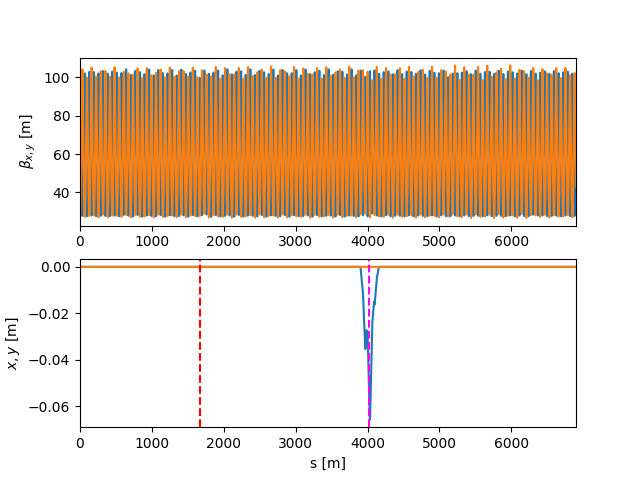

(0.0, 6900.0)

In [193]:
tw_init = line.twiss(continue_on_closed_orbit_error=True, method = '4d')

plt.figure()
ax1 = plt.subplot(2, 1, 1)
plt.plot(tw_init.s, tw_init.betx)
plt.plot(tw_init.s, tw_init.bety)
plt.ylabel(r"$\beta_{x,y}$ [m]")
plt.xlim(0,6900)
ax2 = plt.subplot(2, 1, 2, sharex=ax1)
plt.plot(tw_init.s, tw_init.x)
plt.plot(tw_init.s, tw_init.y)
plt.axvline(tw_init["s", "zs.21633"], color="red", ls="--", label = "ZS entry")
plt.axvline(tw_init["s", "TECA.entry"], color="magenta", ls="--")
plt.ylabel(r"$x,y$ [m]")
plt.xlabel("s [m]")
plt.show()
plt.xlim(0,6900)

### Creating a fine knob for x

                                             
Optimize - start penalty: 0.5519                            
Matching: model call n. 19 penalty = 6.4263e-10              
Optimize - end penalty:  6.42629e-10                            


<Axes: >

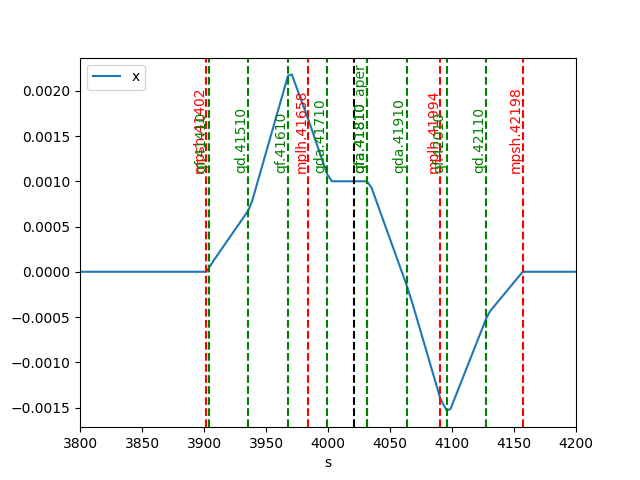

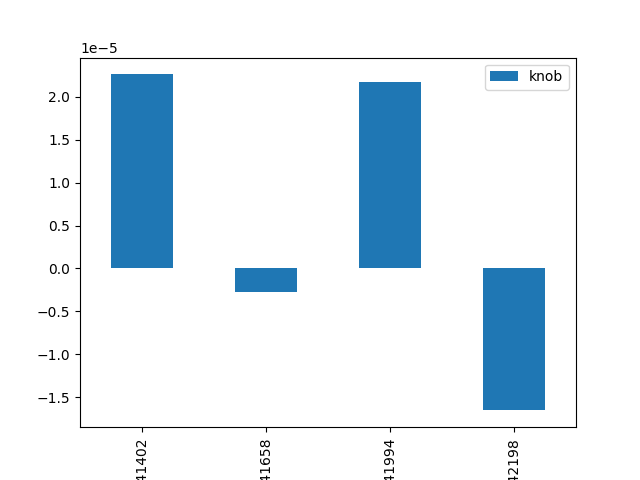

In [194]:
fig, ax = plt.subplots()

line.env["x_teca_knob"] = 0
opt_x_LSS4 = op.set_x_knobLSS4(line)

plot_bump(ax)

settings = {}
for name, knob in bumpers.items():
    settings[name] = line.vv[knob]

settings = pd.DataFrame(settings, index=['knob']).T
settings.plot(kind='bar')

# Creating a fine knob for the angle

In [195]:
line.env["x_mm_knob"] =  0 # mm
for bumper, knob in  bumpers.items():
    line.env[bumper + "_x_init_mm"] = copy(line.vv[knob]) #/ (TECA.tilt * 1e6) # mm normalizing the knob to the TECA tilt
    line.vv[knob] = bumper + "_init" + "*  x_teca_knob + " + bumper + "_x_init_mm * x_mm_knob"

# Angle knob

                                             
Optimize - start penalty: 0.0001                            
Matching: model call n. 13 penalty = 4.2817e-13              
Optimize - end penalty:  4.28173e-13                            


<Axes: >

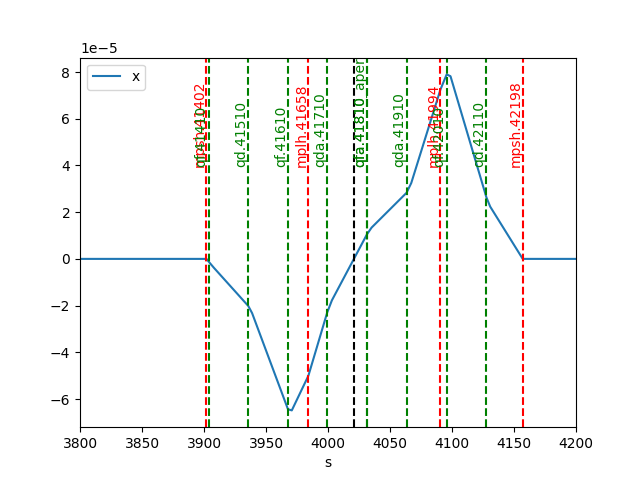

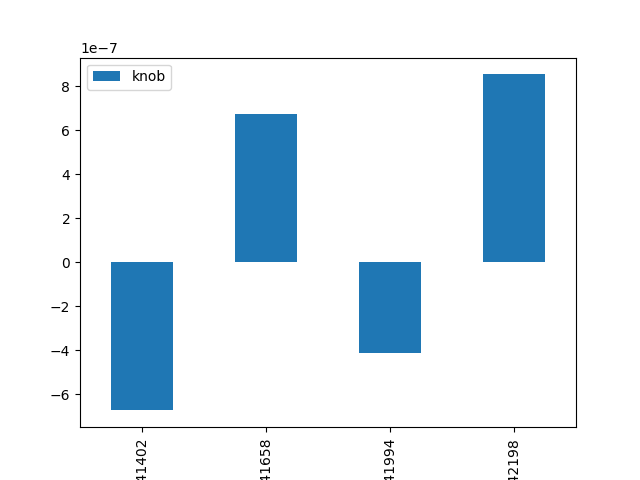

In [196]:
line.vv["x_mm_knob"] =  0
line.vv["x_teca_knob"] =  0


opt_x_LSS4 = op.set_px_knobLSS4(line)

fig, ax = plt.subplots()
plot_bump(ax, show_elements=True)

settings = {}
for name, knob in bumpers.items():
    settings[name] = line.vv[knob]

settings = pd.DataFrame(settings, index=['knob']).T
settings.plot(kind='bar')

## Creating the final expression for the knob

In [197]:
line.env["px_knob_murad"] =  0 # mm
for bumper, knob in bumpers.items():
    line.env[bumper + "_init_px"] = copy(line.vv[knob]) # mm normalizing the knob to the TECA tilt
    line.vv[knob] = bumper + "_init" + "*  x_teca_knob + " + bumper + "_x_init_mm * x_mm_knob +" + bumper + "_init_px * px_knob_murad"

## Checking expectation vs reality

In [198]:
np.linspace(-5, 5, 11)

array([-5., -4., -3., -2., -1.,  0.,  1.,  2.,  3.,  4.,  5.])

In [199]:
x_knob_range = np.linspace(-5, 5, 11)
px_knob_range = np.linspace(-5, 5, 11)

line.vv["x_teca_knob"] = 1

results = {}


for i, x_knob in enumerate(x_knob_range):
    for j, px_knob in enumerate(px_knob_range):
        print(i, j, end='\r')
        line.env["x_mm_knob"] = x_knob 
        line.env["px_knob_murad"] = px_knob 
        tw = line.twiss(continue_on_closed_orbit_error=True, method ="4d").to_pandas()
        tw.index = tw.name
        results[i*len(px_knob_range) + j] = {
            "x_mm": tw.loc['TECA.entry'].x * 1e3,  # Convert to mm
            "px_um": tw.loc['TECA.entry'].px * 1e6,  # Convert to um
            "x_knob": tw_init['x', 'TECA.entry']* 1e3 + x_knob,
            "px_knob": tw_init['px', 'TECA.entry']* 1e6 + px_knob,
        }

results_df = pd.DataFrame.from_dict(results, orient='index')

In [200]:
tw_init['x', 'TECA.entry']

np.float64(-0.052799999999946945)

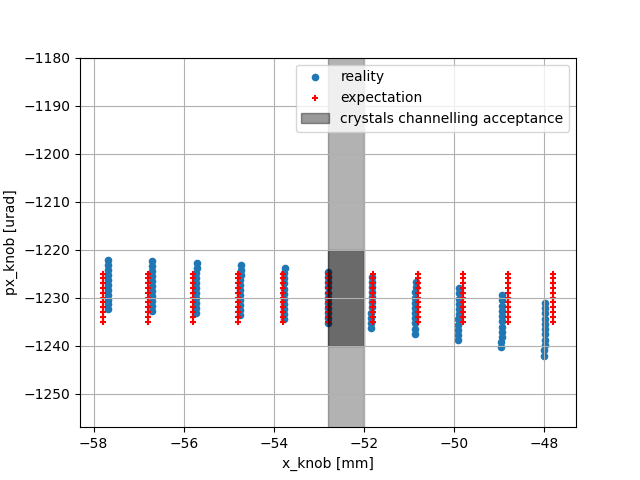

In [201]:
fig, ax = plt.subplots()
results_df.plot.scatter(x='x_mm', y='px_um', marker='o', ax=ax, label='reality')
results_df.plot.scatter(x='x_knob', y='px_knob', marker='+', ax=ax, color='red', label='expectation')
ax.fill_between([TECA.jaw*1e3, TECA.jaw*1e3 - TECA.width*1e3], [TECA.tilt*1e6 - 10]*2, [TECA.tilt*1e6 + 10]*2, color='k', alpha=0.4, label='crystals channelling acceptance')
ax.fill_between([TECA.jaw*1e3, TECA.jaw*1e3 - TECA.width*1e3], -10000, +1000, color='k', alpha=0.3)
ax.set_xlabel('x_knob [mm]')
ax.set_ylabel('px_knob [urad]')
#ax.set_xlim(TECA.jaw*1e3 - TECA.width*1e3 - 4, TECA.jaw*1e3 - TECA.width*1e3 + 2)
ax.set_ylim(TECA.tilt*1e6 - 27, TECA.tilt*1e6 + 50)
ax.legend()
ax.grid(True)
